In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sts
import scipy.special as sp
import matplotlib.pyplot as plt
import seaborn as sns

1\. **Radioactive decay chain**

${\rm Tl}^{208}$ decays to ${\rm Pb}^{208}$ with a half-lieve of 3.052 minutes. Suppose to start with a sample of 1000 Thallium atoms and 0 of Lead atoms.

* Take steps in time of 1 second and at each time-step decide whether each Tl atom has decayed or not, accordingly to the probability $p(t)=1-2^{-t/\tau}$. Subtract the total number of Tl atoms that decayed at each step from the Tl sample and add them to the Lead one. Plot the evolution of the two sets as a function of time  
* Repeat the exercise by means of the inverse transform method: draw 1000 random numbers from the non-uniform probability distribution $p(t)=2^{-t/\tau} \frac{\ln 2}{\tau}$ to represent the times of decay of the 1000 Tl atoms. Make a plot showing the number of atoms that have not decayed as a function of time

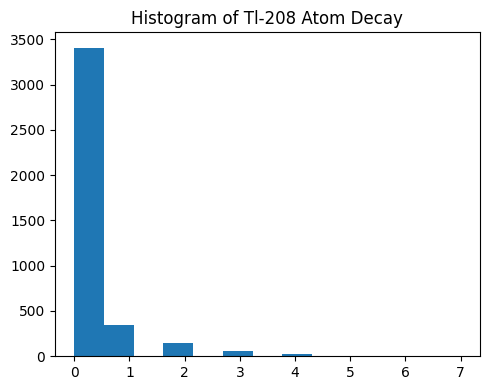

In [2]:
Tl_0 = 1000
Pb_0 = 0
half_life = 3.052 * 60
tau = half_life / np.log(2)

def prob(t: int):
    return 1-2**(-t/tau)

time_steps = 4000
times = np.arange(0, time_steps, 1)

# Direct application of decay function (assume continuity)
ftl = [Tl_0*(1 -  prob(t)) for t in times]
fpb = [Tl_0*(prob(t)) for t in times]

# Stochastic approach (capture randomness of decay events)
Tl_counts = []
Pb_counts = []
decayed_atoms_count = []
for t in times:
    p = 1 - 2 ** (-1 / tau)  # Decay probability per second
    decayed_atoms = np.random.binomial(n=Tl_0, p=p)  # Sample decayed atoms
    decayed_atoms_count.append(decayed_atoms)
    Tl_0 -= decayed_atoms  # Update Tl-208 count
    Pb_0 += decayed_atoms  # Update Pb-208 count
    Tl_counts.append(Tl_0)
    Pb_counts.append(Pb_0)

plt.figure(figsize=(5, 4))
plt.hist(x=decayed_atoms_count, bins='auto')
plt.title('Histogram of Tl-208 Atom Decay')
plt.tight_layout()
plt.show()

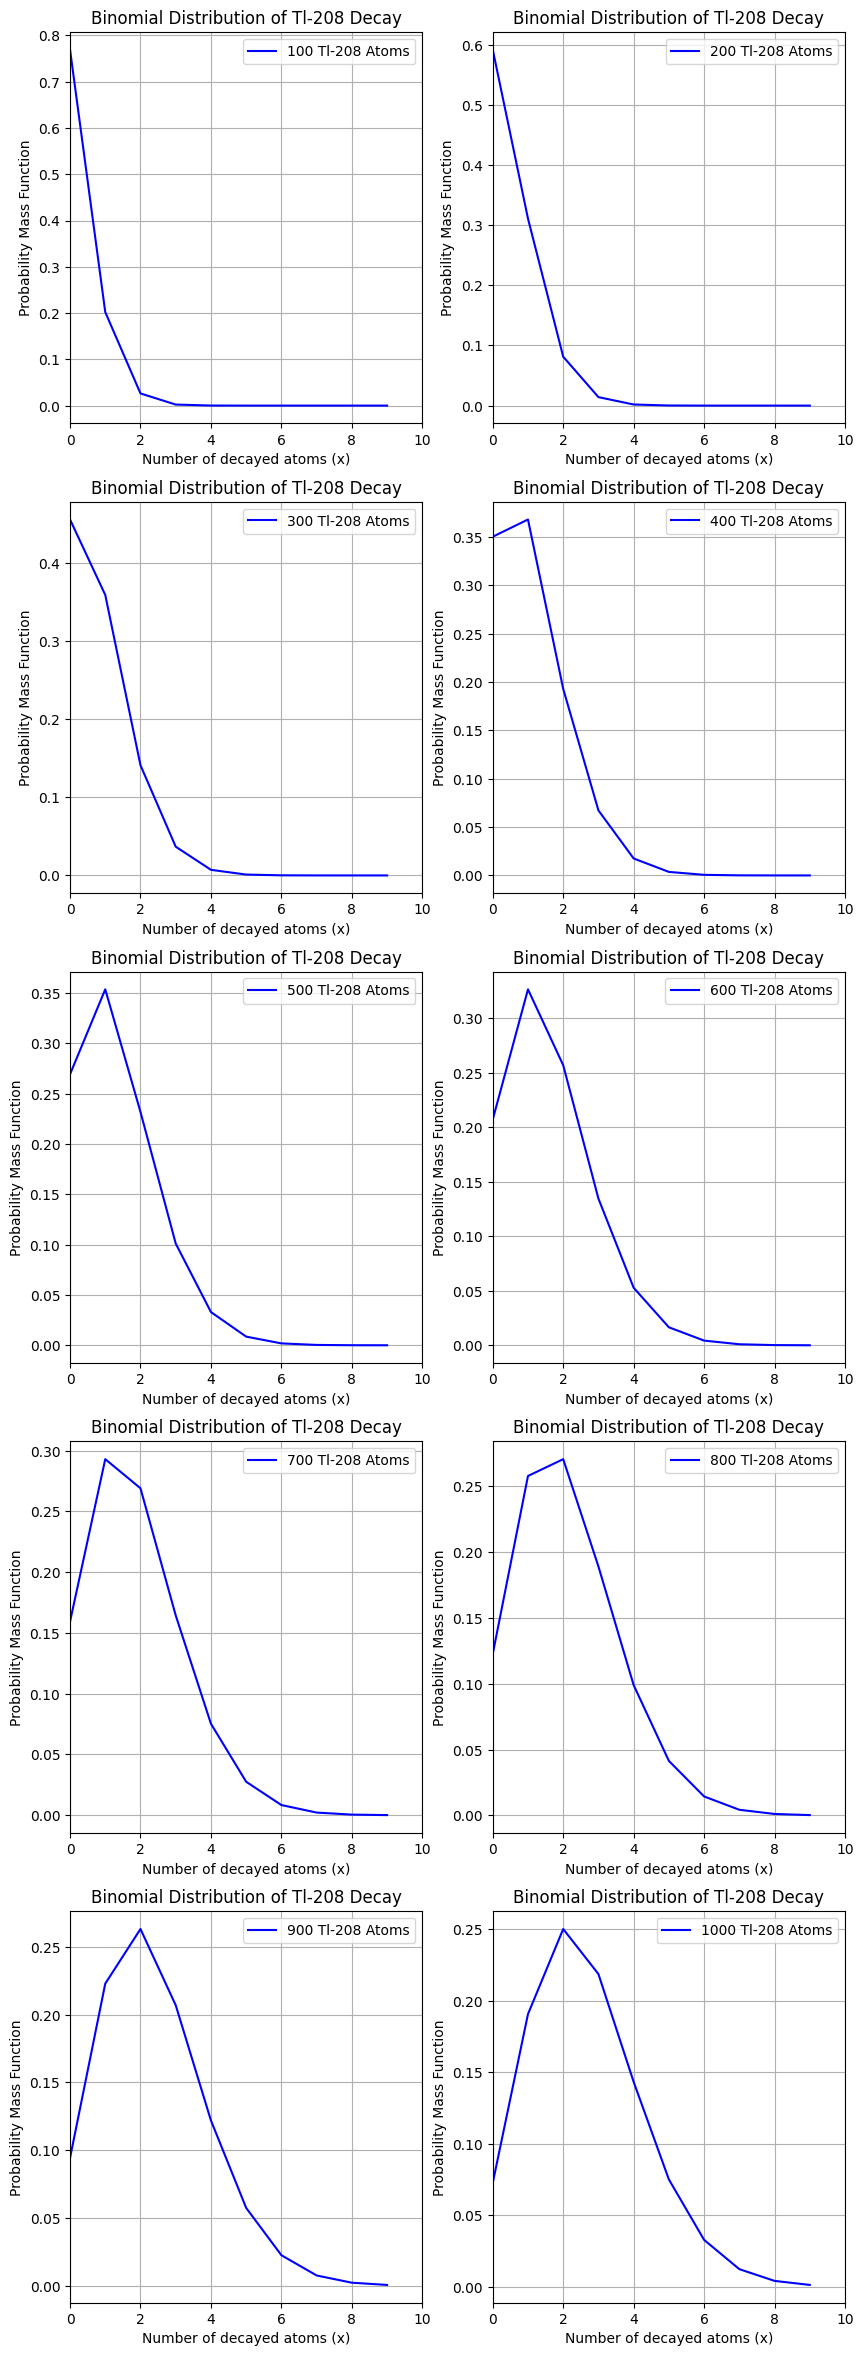

In [3]:
# Values of x (number of decayed atoms)
x = np.arange(0, 10, 1)  # 0 <= x <= 1000
# Plot the function and histogram of sampled atom decays
plt.figure(figsize=(10, 60))
for n in range(1, 11):
    N = 100*n 
    # Compute the binomial probability mass function of all plausible x decays given N
    prob_mass_function = sp.comb(N, x) * (p ** x) * ((1 - p) ** (N - x))
    
    plt.subplot(10, 2, n)
    plt.plot(x, prob_mass_function, color="blue", label=f"{N} Tl-208 Atoms")
    plt.xlabel("Number of decayed atoms (x)")
    plt.xlim(0, 10)
    plt.ylabel("Probability Mass Function")
    plt.title("Binomial Distribution of Tl-208 Decay")
    plt.grid()
    plt.legend()

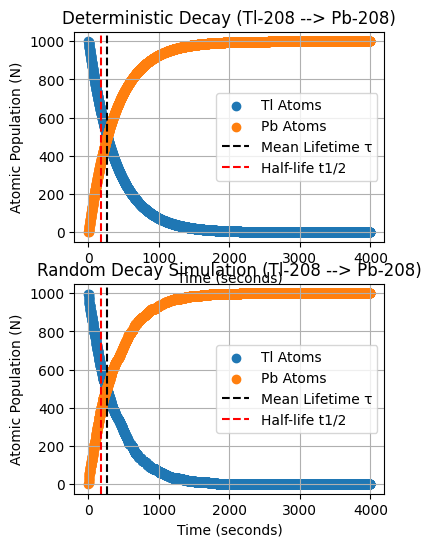

In [4]:
plt.figure(figsize=(4,6))
plt.subplot(2, 1, 1)
plt.scatter(x=times, y=ftl, label='Tl Atoms')
plt.scatter(x=times, y=fpb, label='Pb Atoms')
plt.title('Deterministic Decay (Tl-208 --> Pb-208)')
plt.xlabel('Time (seconds)')
plt.ylabel('Atomic Population (N)')

plt.axvline(x=tau, color='black', linestyle='--', label="Mean Lifetime τ")
plt.axvline(x=half_life, color='red', linestyle='--', label="Half-life t1/2")
plt.grid()
plt.legend()

plt.subplot(2, 1, 2)
plt.scatter(x=times, y=Tl_counts, label='Tl Atoms')
plt.scatter(x=times, y=Pb_counts, label='Pb Atoms')
plt.title('Random Decay Simulation (Tl-208 --> Pb-208)')
plt.xlabel('Time (seconds)')
plt.ylabel('Atomic Population (N)')

plt.axvline(x=tau, color='black', linestyle='--', label="Mean Lifetime τ")
plt.axvline(x=half_life, color='red', linestyle='--', label="Half-life t1/2")
plt.grid()
plt.legend()
plt.tight_layout
plt.show()

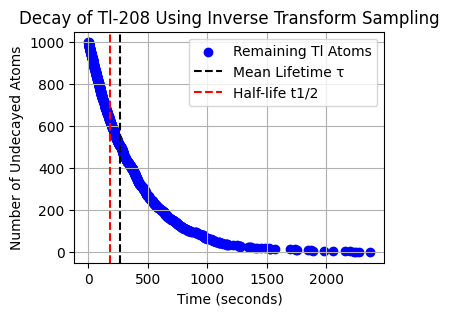

In [5]:
u = np.random.rand(1000)
decay_times = -tau * np.log2(1 - u)

decay_times = np.sort(decay_times)

Tl_remaining = 1000 - np.arange(1, 1001)
plt.figure(figsize=(4, 3))
plt.scatter(decay_times, Tl_remaining, label="Remaining Tl Atoms", color="blue")
plt.xlabel("Time (seconds)")
plt.ylabel("Number of Undecayed Atoms")

plt.title("Decay of Tl-208 Using Inverse Transform Sampling")
plt.axvline(x=tau, color='black', linestyle='--', label="Mean Lifetime τ")
plt.axvline(x=half_life, color='red', linestyle='--', label="Half-life t1/2")
plt.legend()
plt.grid()
plt.show()

2\. **Rutherford Scattering**

The scattering angle $\theta$ of $\alpha$ particles hitting a positively charged nucleus of a Gold atom ($Z=79$) follows the rule:

$$
\tan{\frac{1}{2} \theta} = \frac{Z e^2} {2\pi \epsilon_0 E b}
$$

where $E=7.7$ MeV and $b$ beam is the impact parameter. The beam is represented by a 2D gaussian distribution with $\sigma=a_0/100$ for both coordinates ($a_0$ being the Bohr radius). Assume 1 million $\alpha$ particles are shot on the gold atom.

Computing the fraction of particles that "bounce back",i.e. those particle whose scattering angle is greater than $\pi/2$ (which set a condition on the impact parameter $b$)

Fraction of alpha particles that bounce back: 0.044381


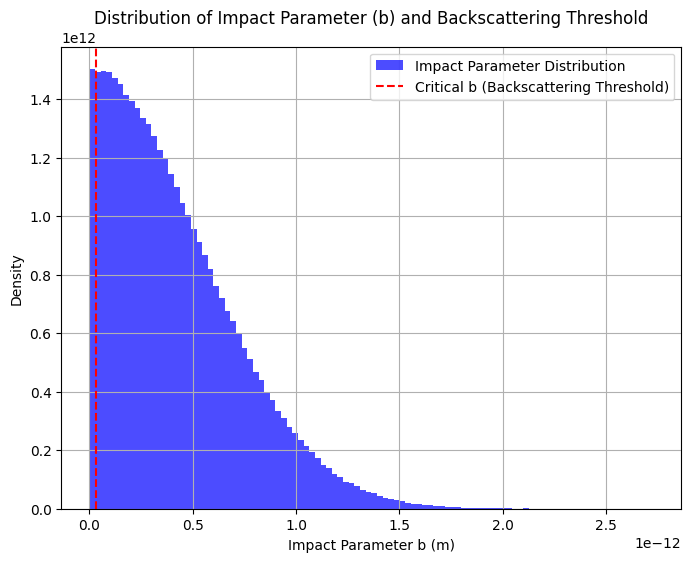

In [6]:
# Constants
Z = 79  # Gold nucleus charge
e = 1.602e-19  # Elementary charge (Coulombs)
epsilon_0 = 8.854e-12  # Vacuum permittivity (F/m)
E_MeV = 7.7  # Energy in MeV
E = E_MeV * 1.602e-13  # Convert MeV to Joules
a0 = 5.29177e-11  # Bohr radius (meters)
sigma_b = a0 / 100  # Standard deviation of impact parameter

# Critical impact parameter threshold for backscattering
b_critical = (Z * e**2) / (2 * np.pi * epsilon_0 * E)

# Generate 1 million impact parameters following a Gaussian distribution
N_particles = 10**6
b_values = np.abs(np.random.normal(0, sigma_b, N_particles))  # Absolute values for physical constraints

# Compute the fraction of particles that satisfy b < b_critical
backscattered_fraction = np.sum(b_values < b_critical) / N_particles

# Display result
print(f"Fraction of alpha particles that bounce back: {backscattered_fraction:.6f}")

# Plot histogram of impact parameters
plt.figure(figsize=(8, 6))
plt.hist(b_values, bins=100, alpha=0.7, color='blue', density=True, label="Impact Parameter Distribution")
plt.axvline(
    b_critical,
    color='red',
    linestyle='--',
    label="Critical b (Backscattering Threshold)",
)
plt.xlabel("Impact Parameter b (m)")
plt.ylabel("Density")
plt.title("Distribution of Impact Parameter (b) and Backscattering Threshold")
plt.legend()
plt.grid()
plt.show()

3\. **Monte Carlo integration: hit/miss vs mean value method**

Consider the function 

$$f(x) =\sin^2{\frac{1}{x(2-x)}}$$

* Compute the integral of $f(x)$ between 0 and 2 with the hit/miss method. Evaluate the error of your estimate
* Repeat the integral with the mean value method. Evaluate the error and compare it with the previous one

Box enclosing the function is of area A=2


Text(0, 0.5, '$f(x)$')

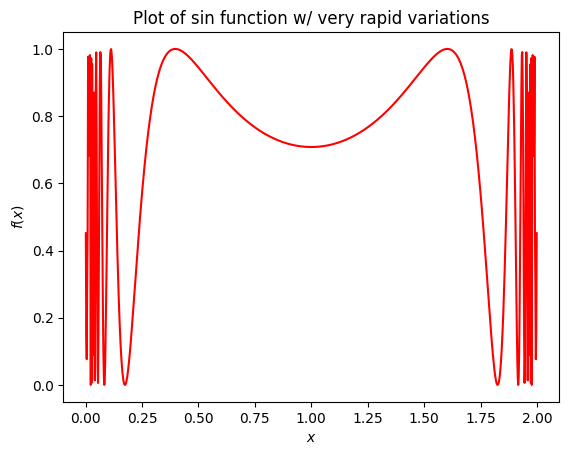

In [7]:
def f(x):
    return (np.sin(1/(x*(2-x))))**2

x = np.linspace(0.001, 1.999, 1000)
A = 2
print(f"Box enclosing the function is of area A={A}")
plt.plot(x, f(x), 'r-')
plt.title('Plot of sin function w/ very rapid variations')
plt.xlabel('$x$')
plt.ylabel('$f(x)$')


In [8]:
# Hit/miss method
N = 10000
k = 0
for _ in range(N):
    x = 2*np.random.random()
    y = np.random.random()
    if y<f(x): k += 1
I_h = k * A / N

In [9]:
# Mean value method
a = 0
b = 2
y_values = []
for _ in range(N):
    x = 2*np.random.random()
    y_values.append(f(x))
I_m = (b - a) * sum(y_values) / N
print(f'Hit/Miss method gives <I> = {I_h:.4f}')
print()
print(f'Mean values method gives <I> = {I_m:.4f}')

Hit/Miss method gives <I> = 1.4532

Mean values method gives <I> = 1.4464


4\. **Monte Carlo integration in high dimension**

* Start of by computing the area of a circle of unit radius, by integrating the function 

$$
f(x,y)=
\left\{
\begin{array}{ll}
      1 & x^2+y^2\le 1 \\
      0 & {\rm elsewhere}
\end{array} 
\right.
$$

* Generalize the result for a 10D sphere


In [10]:
x, y = np.random.uniform(-1, 1, N), np.random.uniform(-1, 1, N)

A = (x.max() - x.min()) * (y.max() - y.min())

k = x**2 + y**2 <= 1
I_c = np.sum(k) * A / N

print(f"Area of the unit circle given my <I> = {I_c:.4f}")
print(f"numpy value for pi: {np.pi}")

Area of the unit circle given my <I> = 3.1218
numpy value for pi: 3.141592653589793


In [11]:
#   Generalize the result for a 10D sphere
N = 10**6
dims = 10

vars = np.zeros(shape=(N, dims))
for d in range(dims):
    vars[:, d] = np.random.uniform(-1, 1, N)

X = np.random.uniform(-1, 1, (N, dims))

A = 2**dims

k = [sum(vars[i, :]**2) <= 1 for i in range(N)]
k2 = np.sum(X**2, axis=1) <=1

I = np.sum(k) * A / N
I2 = np.sum(k2) * A / N

print(I, "\n", I2)

2.578432 
 2.537472


5\. **Monte Carlo integration with importance sampling** 

Calculate the value of the integral:

$$
I=\int_0^1 \frac{x^{-1/2}}{e^x+1} dx
$$

using the importance sampling method with $w(x)=1/\sqrt{x}$. You should get a result about 0.84

In [12]:
def f(x):
    if x.any() == 0: 
        return ValueError('f(0) cannot be evaluate')
    Num = x**( -1/2 )
    Den = np.exp(x) + 1
    return Num / Den

N = 10**6
a, b = np.array((0)), np.array((1))

u = np.random.uniform(0, 1, N)

I_mean = (b - a) * np.mean(f(u))

print(f'Using the mean value method: <I_mv> = {I_mean:.6f}')

Using the mean value method: <I_mv> = 0.839039


In [16]:
print('The hit/miss method cannot be used as f(0) is undefined\ni.e., the area under the curve cannot be calculated effectively')

The hit/miss method cannot be used as f(0) is undefined
i.e., the area under the curve cannot be calculated effectively


In [14]:
# p(x) is given by f(x)/w(x) = 1 / (exp(x) + 1)
# also the integral of w(x) from 0 to 1 in x gives 2 
# so the cdf of that pdf is (x)^(1/2) and the inverse of the cdf is x = u**2

def p(x):
    return 1 / (np.exp(x) + 1)

x_samples = u**2

I_imp = 2 * np.mean(p(x_samples))

print(f'Using the importance sampling method: <I_is> = {I_imp:.6f}')

Using the importance sampling method: <I_is> = 0.839249
